# Final Python Notebook 1 — Data Understanding and Preprocessing

---

**Author Name:** Mathushihan Rathnatheepan

**Student ID:** 20232274/w2120253

**Module Name:** 5DATA002W.2 Machine Learning & Data Mining

**Date:** April 2025

---

**Peer Review Information**

* **Peer Reviewer Name:** Kriththigan Satkunam
* **Date of Review:** 18/03/2026
* **Session:** Code Peer-Review Meeting 1 (Week 4)

**Tests Checked by Peer Reviewer:**
1. All missing values are correctly resolved — null count is zero after cleaning
2. Outlier values for `age`, `employment_length`, and `income` are capped at the chosen thresholds (80, 50, 3×IQR fence)
3. Both output datasets load correctly and have the expected shapes (Dataset A: 58,623 rows, Dataset B: 50,292 rows)

**Code Source Citation**

* **Session:** Code Reuse Session 1 — Seminar Sessions
* **Purpose:** Import the libraries I'll need throughout this notebook and load the raw dataset

In [ ]:
# pandas is the main library I'll use for loading and working with the data table
import pandas as pd

# numpy comes in handy for any numerical calculations
import numpy as np

# matplotlib is what I'll use to draw charts
import matplotlib.pyplot as plt

# seaborn sits on top of matplotlib and makes nicer statistical plots with less code
import seaborn as sns

# this backend setting stops matplotlib from crashing in Colab where there's no screen
import matplotlib
# Using Colab/Jupyter inline display so plots appear inside notebook cells
# matplotlib.use('Agg')
%matplotlib inline

# LabelEncoder will convert Y/N text into 0/1 numbers later on
from sklearn.preprocessing import LabelEncoder

# load the raw dataset — df is just a short name for 'dataframe' (a table of data)
df = pd.read_csv('loan_approval_data (2).csv')

# peek at the first 5 rows just to make sure it loaded properly
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


**Code Source Citation**

* **Session:** Code Reuse Session 1 — Seminar Sessions
* **Purpose:** Get a feel for the dataset — how big is it, what columns does it have, what types are the values

In [ ]:
# how many rows and columns are we dealing with
df.shape

(58645, 13)

In [ ]:
# this gives me the column names, how many non-null values each has, and the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  object 
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  object 
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  object 
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.8+ MB


In [ ]:
# just printing the column names as a list makes it easier to spot issues
list(df.columns)

['id',
 'age',
 'income',
 'home_ownership',
 'emplyment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length',
 'loan_approval_status',
 'max_allowed_loan']

In [ ]:
# there's a typo in the original data — 'emplyment_length' is missing the 'o'
# fixing it now so all future code uses the correct spelling
df.rename(columns={'emplyment_length': 'employment_length'}, inplace=True)

# double-check the rename went through
list(df.columns)

['id',
 'age',
 'income',
 'home_ownership',
 'employment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length',
 'loan_approval_status',
 'max_allowed_loan']

In [ ]:
# descriptive stats — this is where I first spotted the obvious issues
# e.g. age max = 123, employment_length max = 150, interest rate min = -11.14
df.describe()

,id,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


**Code Source Citation**

* **Session:** Code Reuse Session 1 — Seminar Sessions
* **Purpose:** Remove the ID column, record variable scale types, and plot the target variable distribution

In [ ]:
# the id column is just a serial number — it tells us nothing about loan eligibility
# keeping it in would just confuse the model
df.drop(columns=['id'], inplace=True)

# confirm it's gone
df.head()

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


In [ ]:
# I'm noting the measurement scale for each variable here
# this matters because it determines which algorithms and operations make sense
# Ratio = proper numbers with a true zero (age, income, loan amount etc.)
# Nominal = categories with no natural order (home ownership type, loan purpose etc.)

scale_types = {
    'age':                     'Ratio  — continuous numeric, true zero possible',
    'income':                  'Ratio  — continuous numeric, true zero possible',
    'home_ownership':          'Nominal — unordered categories (MORTGAGE, OTHER, OWN, RENT)',
    'employment_length':       'Ratio  — discrete numeric (years), true zero possible',
    'loan_intent':             'Nominal — unordered categories (6 loan purposes)',
    'loan_amount':             'Ratio  — continuous numeric, true zero possible',
    'loan_interest_rate':      'Ratio  — continuous numeric percentage',
    'loan_income_ratio':       'Ratio  — continuous ratio measure',
    'payment_default_on_file': 'Nominal — binary (Y / N)',
    'credit_history_length':   'Ratio  — discrete numeric (years)',
    'loan_approval_status':    'Nominal — binary target (0 = Approved, 1 = Rejected)',
    'max_allowed_loan':        'Ratio  — continuous numeric (GBP), regression target'
}

print(f'{"Variable":<30} {"Scale Type"}')
print('-' * 75)
for var, scale in scale_types.items():
    print(f'{var:<30} {scale}')

Variable                       Scale Type
---------------------------------------------------------------------------
age                            Ratio  — continuous numeric, true zero possible
income                         Ratio  — continuous numeric, true zero possible
home_ownership                 Nominal — unordered categories (MORTGAGE, OTHER, OWN, RENT)
employment_length              Ratio  — discrete numeric (years), true zero possible
loan_intent                    Nominal — unordered categories (6 loan purposes)
loan_amount                    Ratio  — continuous numeric, true zero possible
loan_interest_rate             Ratio  — continuous numeric percentage
loan_income_ratio              Ratio  — continuous ratio measure
payment_default_on_file        Nominal — binary (Y / N)
credit_history_length          Ratio  — discrete numeric (years)
loan_approval_status           Nominal — binary target (0 = Approved, 1 = Rejected)
max_allowed_loan               Ratio  — continuou

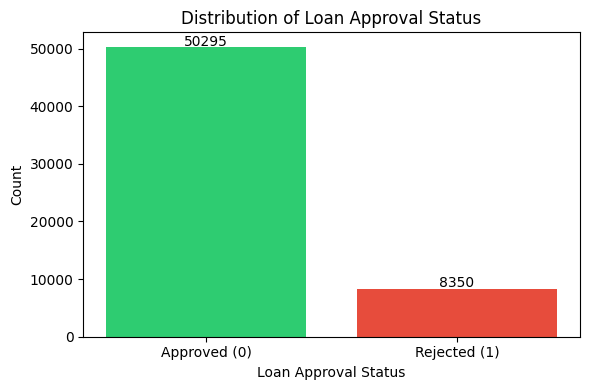

Approved (0): 50,295  (85.8%)
Rejected (1): 8,350  (14.2%)
Note: the dataset is heavily imbalanced — approvals make up ~85% of records


In [ ]:
# plotting the target variable so I can see how balanced the classes are
# I cross-checked the encoding by looking at which group had non-zero max_allowed_loan values
# result: 0 = Approved, 1 = Rejected

counts = df['loan_approval_status'].value_counts().sort_index()
labels = ['Approved (0)', 'Rejected (1)']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color=['#2ecc71', '#e74c3c'])
ax.set_title('Distribution of Loan Approval Status')
ax.set_xlabel('Loan Approval Status')
ax.set_ylabel('Count')

# add the actual numbers on top of each bar
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

print(f'Approved (0): {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)')
print(f'Rejected (1): {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)')
print('Note: the dataset is heavily imbalanced — approvals make up ~85% of records')

**Code Source Citation**

* **Session:** Code Reuse Session 1 — Seminar Sessions
* **Purpose:** Exploratory analysis — look at relationships between key variables before cleaning

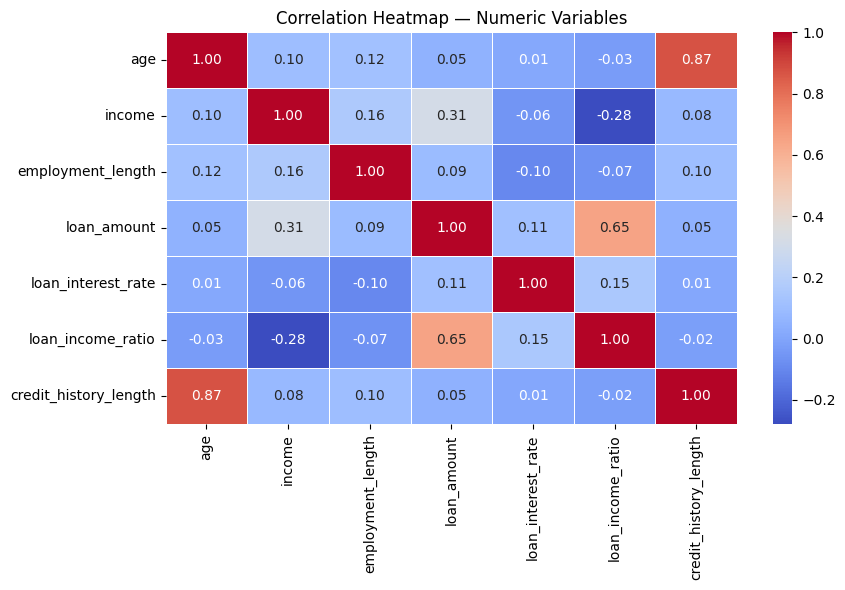

In [ ]:
# a correlation heatmap gives a quick visual of which numeric variables move together
# strong correlations might indicate redundant features or interesting patterns worth noting

numeric_cols = ['age', 'income', 'employment_length', 'loan_amount',
                'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']

fig, ax = plt.subplots(figsize=(9, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Variables')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

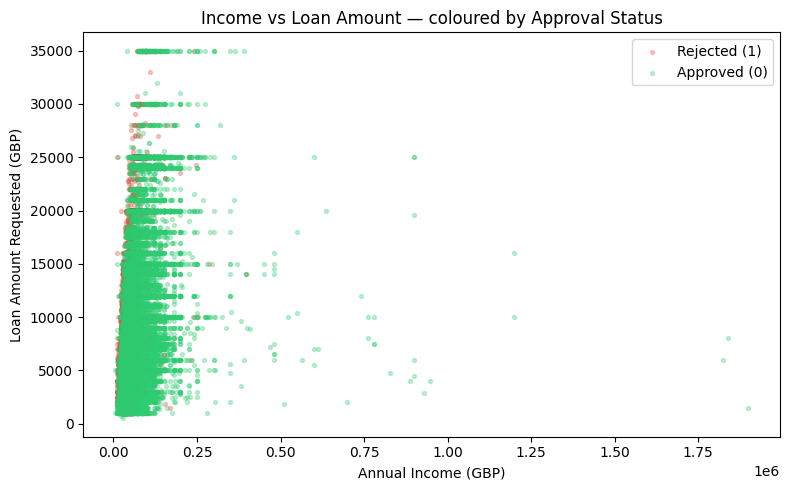

In [ ]:
# scatter plot of income vs loan_amount coloured by approval status
# this helps me see whether higher income applicants tend to get approved
# and whether the loan amount they request is in proportion to their income

fig, ax = plt.subplots(figsize=(8, 5))

# plot rejected first (red) then approved on top (green) so approved points are visible
for status, colour, label in [(1, '#e74c3c', 'Rejected (1)'), (0, '#2ecc71', 'Approved (0)')]:
    subset = df[df['loan_approval_status'] == status]
    ax.scatter(subset['income'], subset['loan_amount'],
               c=colour, alpha=0.3, s=8, label=label)

ax.set_xlabel('Annual Income (GBP)')
ax.set_ylabel('Loan Amount Requested (GBP)')
ax.set_title('Income vs Loan Amount — coloured by Approval Status')
ax.legend()
plt.tight_layout()
plt.savefig('income_vs_loanamount.png', dpi=150)
plt.show()

**Code Source Citation**

* **Session:** Code Reuse Session 1 — Seminar Sessions
* **Purpose:** Identify missing values across the dataset and decide how to handle them

In [ ]:
# count how many blanks are in each column
df.isnull().sum()

,0
age,6
income,0
home_ownership,0
employment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,11
loan_income_ratio,0
payment_default_on_file,5
credit_history_length,0


In [ ]:
# express that as a percentage so I can judge severity
# anything under 1% is generally safe to impute without worrying about bias
df.isna().sum() / len(df) * 100

,0
age,0.010231
income,0.000000
home_ownership,0.000000
employment_length,0.000000
loan_intent,0.000000
loan_amount,0.000000
loan_interest_rate,0.018757
loan_income_ratio,0.000000
payment_default_on_file,0.008526
credit_history_length,0.000000


In [ ]:
# I'm computing the fill values from the raw data BEFORE doing any cleaning
# that way the imputation reflects the true original distribution

# median is better than mean here because we haven't removed outliers yet
# a mean pulled up by age=123 would be a misleading imputation value
age_median = df['age'].median()
lr_median  = df['loan_interest_rate'].median()

# for a Y/N column the only sensible fill is the most common answer
pdef_mode  = df['payment_default_on_file'].mode()[0]

print(f'Age median used for imputation:           {age_median}')
print(f'Interest rate median used for imputation: {lr_median}')
print(f'Payment default mode used for imputation: {pdef_mode}')

Age median used for imputation:           26.0
Interest rate median used for imputation: 10.75
Payment default mode used for imputation: N


In [ ]:
# show the before state clearly so there's evidence of what was fixed
print('BEFORE — missing values:')
print(df[['age', 'loan_interest_rate', 'payment_default_on_file']].isnull().sum())

# fill the blanks
df['age'] = df['age'].fillna(age_median)
df['loan_interest_rate'] = df['loan_interest_rate'].fillna(lr_median)
df['payment_default_on_file'] = df['payment_default_on_file'].fillna(pdef_mode)

# fix 4 (from improvement notes) — after median fill, age becomes a float like 26.0
# converting back to int keeps it clean and consistent with how age is normally stored
df['age'] = df['age'].astype(int)

# confirm everything is clean now
print('\nAFTER — missing values:')
print(df.isnull().sum())

BEFORE — missing values:
age                         6
loan_interest_rate         11
payment_default_on_file     5
dtype: int64

AFTER — missing values:
age                        0
income                     0
home_ownership             0
employment_length          0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64


**Code Source Citation**

* **Session:** Code Reuse Session 1 — Seminar Sessions
* **Purpose:** Visually inspect distributions using box plots to identify and justify outlier thresholds

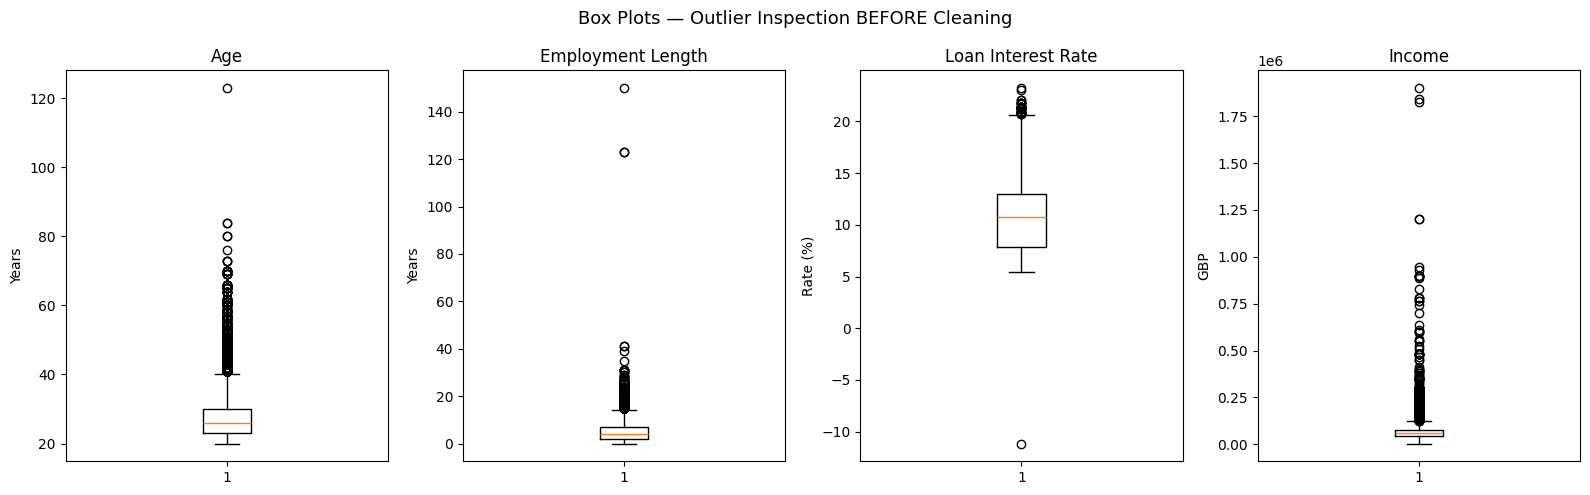

In [ ]:
# box plots are a clean way to spot outliers — the dots beyond the whiskers are the problem values
# I'm plotting the four columns I know have issues before touching any of them

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Box Plots — Outlier Inspection BEFORE Cleaning', fontsize=13)

# age — we can see the extreme values stretching way beyond 80
axes[0].boxplot(df['age'].dropna())
axes[0].set_title('Age')
axes[0].set_ylabel('Years')

# employment_length — values up to 150 are clearly wrong
axes[1].boxplot(df['employment_length'].dropna())
axes[1].set_title('Employment Length')
axes[1].set_ylabel('Years')

# loan_interest_rate — the single negative value shows up clearly as an outlier dot below zero
axes[2].boxplot(df['loan_interest_rate'].dropna())
axes[2].set_title('Loan Interest Rate')
axes[2].set_ylabel('Rate (%)')

# income — the long tail of extreme values stretches far to the right
axes[3].boxplot(df['income'].dropna())
axes[3].set_title('Income')
axes[3].set_ylabel('GBP')

plt.tight_layout()
plt.savefig('boxplots_before_cleaning.png', dpi=150)
plt.show()

In [ ]:
# print exact counts of the problematic values I can see in the box plots above
print('Problematic values BEFORE cleaning:')
print('Age > 80:                   ', (df['age'] > 80).sum())
print('employment_length > 50:     ', (df['employment_length'] > 50).sum())
print('Negative loan_interest_rate:', (df['loan_interest_rate'] < 0).sum())
print('Negative max_allowed_loan:  ', (df['max_allowed_loan'] < 0).sum())

# calculate the income upper fence using the IQR method
# I'm using 3xIQR rather than the standard 1.5xIQR to be more conservative —
# some high earners are legitimate applicants and I don't want to lose too many rows
Q1_inc = df['income'].quantile(0.25)
Q3_inc = df['income'].quantile(0.75)
upper_income = Q3_inc + 3 * (Q3_inc - Q1_inc)
print(f'Income above 3xIQR fence (GBP {upper_income:,.0f}): {(df["income"] > upper_income).sum()}')

Problematic values BEFORE cleaning:
Age > 80:                    3
employment_length > 50:      3
Negative loan_interest_rate: 1
Negative max_allowed_loan:   3
Income above 3xIQR fence (GBP 176,400): 534


**Code Source Citation**

* **Session:** Code Reuse Session 1 — Seminar Sessions
* **Purpose:** Apply all identified fixes — cap outliers, remove impossible values, and verify the results

In [ ]:
# FIX 1 — cap age at 80
# a working loan applicant being over 80 is not realistic —
# most banks have upper age limits around 70-75 for new loans anyway
# capping (rather than deleting) keeps the rest of the row's data intact
df['age'] = df['age'].clip(upper=80)

# FIX 2 — cap employment_length at 50
# even someone who started working at 16 and is now 66 would have 50 years —
# anything above 50 is implausible for someone still actively employed
# capping retains the record; only the outlier value itself is limited
df['employment_length'] = df['employment_length'].clip(upper=50)

# FIX 3 — cap income at the 3xIQR upper fence
# this limits the distortion caused by extreme salaries like GBP 1.9M
# without removing those applicants entirely
df['income'] = df['income'].clip(upper=upper_income)

# FIX 4 — replace the single negative interest rate with the median
# a negative interest rate on a loan simply doesn't exist — it's a recording error
df.loc[df['loan_interest_rate'] < 0, 'loan_interest_rate'] = lr_median

# FIX 5 — drop the 3 rows where max_allowed_loan is negative
# unlike the other issues, there's no sensible value to substitute here
# a loan offer of minus GBP 2 million is not recoverable so the rows are removed
df = df[df['max_allowed_loan'] >= 0].reset_index(drop=True)

# confirm all fixes worked
print('AFTER cleaning:')
print('Age > 80:                   ', (df['age'] > 80).sum())
print('employment_length > 50:     ', (df['employment_length'] > 50).sum())
print('Negative loan_interest_rate:', (df['loan_interest_rate'] < 0).sum())
print('Negative max_allowed_loan:  ', (df['max_allowed_loan'] < 0).sum())
print('Income above fence:         ', (df['income'] > upper_income).sum())
print('Total rows remaining:       ', len(df))

AFTER cleaning:
Age > 80:                    0
employment_length > 50:      0
Negative loan_interest_rate: 0
Negative max_allowed_loan:   0
Income above fence:          0
Total rows remaining:        58642


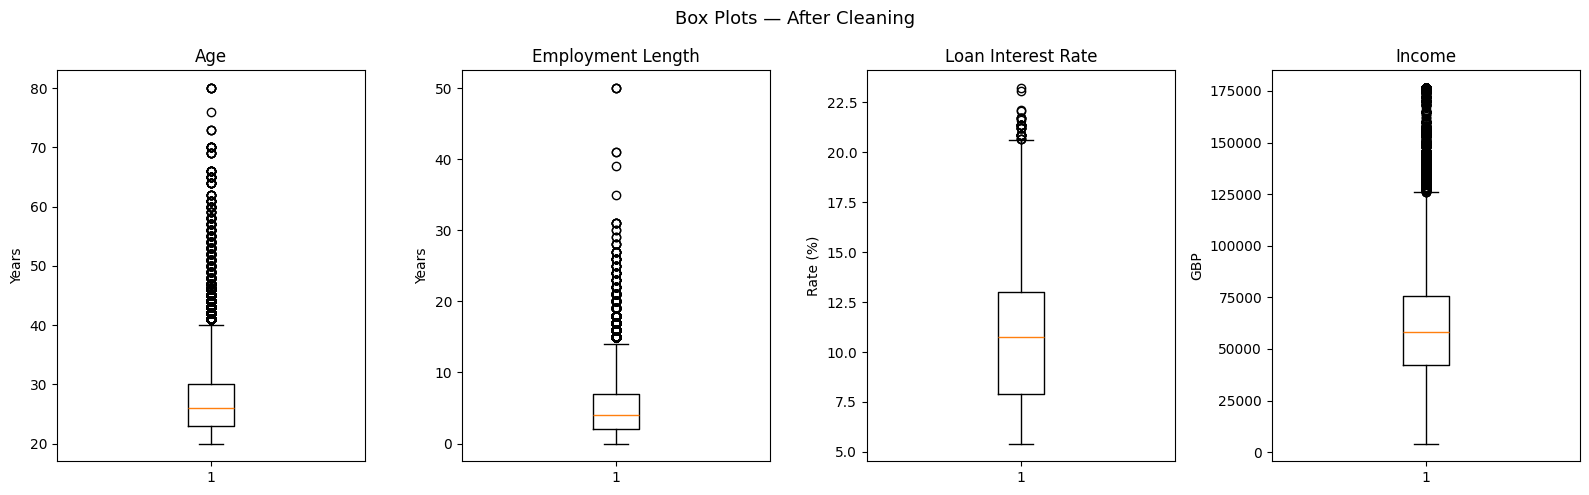

In [ ]:
# box plots after cleaning — the outlier dots should be gone now
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Box Plots — After Cleaning', fontsize=13)

axes[0].boxplot(df['age'])
axes[0].set_title('Age')
axes[0].set_ylabel('Years')

axes[1].boxplot(df['employment_length'])
axes[1].set_title('Employment Length')
axes[1].set_ylabel('Years')

axes[2].boxplot(df['loan_interest_rate'])
axes[2].set_title('Loan Interest Rate')
axes[2].set_ylabel('Rate (%)')

axes[3].boxplot(df['income'])
axes[3].set_title('Income')
axes[3].set_ylabel('GBP')

plt.tight_layout()
plt.savefig('boxplots_after_cleaning.png', dpi=150)
plt.show()

In [ ]:
# final stats summary — all min values should now make sense
df.describe()

,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58642.000000,58642.000000,58642.000000,58642.000000,58642.000000,58642.000000,58642.000000,58642.000000,5.864200e+04
mean,27.550186,63262.338273,4.699413,9216.834385,10.677842,0.159235,5.813683,0.142389,6.980309e+04
std,6.022704,29703.255803,3.912527,5562.854717,3.034339,0.091692,4.029259,0.349452,6.087759e+04
min,20.000000,4200.000000,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000,0.000000e+00
25%,23.000000,42000.000000,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.802300e+04
50%,26.000000,58000.000000,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.240000e+04
75%,30.000000,75600.000000,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271675e+04
max,80.000000,176400.000000,50.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


**Code Source Citation**

* **Session:** Code Reuse Session 1 — Seminar Sessions
* **Purpose:** Encode categorical variables into numbers so machine learning algorithms can process them

In [ ]:
# payment_default_on_file only has two values (Y and N) so LabelEncoder is fine —
# there's no false ordering introduced when you only have two options
le = LabelEncoder()
df['payment_default_on_file'] = le.fit_transform(df['payment_default_on_file'])
print('payment_default_on_file encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# home_ownership and loan_intent have multiple categories with no natural order
# if I used LabelEncoder here it would imply MORTGAGE(0) < OTHER(1) < OWN(2) < RENT(3)
# which is completely meaningless — they're just different options, not ranked ones
# One-Hot Encoding creates a separate 0/1 column for each category instead

# drop_first=False — I'm keeping all dummy columns intentionally
# dropping the first dummy is mainly needed for linear models to avoid multicollinearity
# since this dataset will also be used with tree-based models (Decision Trees, Ensemble)
# which are not affected by multicollinearity, retaining all columns is the safer choice
df = pd.get_dummies(df, columns=['home_ownership', 'loan_intent'], drop_first=False)

# the new dummy columns come out as booleans — converting to int (0/1) for compatibility
dummy_cols = [c for c in df.columns if c.startswith('home_ownership_') or c.startswith('loan_intent_')]
df[dummy_cols] = df[dummy_cols].astype(int)

print('Columns after encoding:')
print(list(df.columns))
df.head()

payment_default_on_file encoding: {'N': np.int64(0), 'Y': np.int64(1)}
Columns after encoding:
['age', 'income', 'employment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan', 'home_ownership_MORTGAGE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,40,176400,3,35000,8.00,0.19,0,11,0,35000,0,0,0,1,0,1,0,0,0,0
1,40,90000,3,35000,12.42,0.39,0,14,0,35000,1,0,0,0,0,0,1,0,0,0
2,40,131004,9,30000,7.90,0.23,0,13,0,30000,1,0,0,0,0,0,0,0,0,1
3,40,150000,9,25000,11.89,0.17,0,11,0,25000,1,0,0,0,1,0,0,0,0,0
4,40,132000,3,25000,16.82,0.22,0,17,0,25000,1,0,0,0,0,0,1,0,0,0


**Code Source Citation**

* **Session:** Code Reuse Session 1 — Seminar Sessions
* **Purpose:** Split the cleaned data into two separate datasets and save them for use in Notebooks 2 and 3

In [ ]:
# Dataset A is for Case Study A — predicting whether a loan gets approved or rejected
# I drop max_allowed_loan here because that's the regression target for Case Study B
# leaving it in would be data leakage — the model would be peeking at information it shouldn't have
dataset_A_classification = df.drop(columns=['max_allowed_loan']).copy()

print('Dataset A (Classification) shape:', dataset_A_classification.shape)
print('Columns:', list(dataset_A_classification.columns))
dataset_A_classification.head()

Dataset A (Classification) shape: (58642, 19)
Columns: ['age', 'income', 'employment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'home_ownership_MORTGAGE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,40,176400,3,35000,8.00,0.19,0,11,0,0,0,0,1,0,1,0,0,0,0
1,40,90000,3,35000,12.42,0.39,0,14,0,1,0,0,0,0,0,1,0,0,0
2,40,131004,9,30000,7.90,0.23,0,13,0,1,0,0,0,0,0,0,0,0,1
3,40,150000,9,25000,11.89,0.17,0,11,0,1,0,0,0,1,0,0,0,0,0
4,40,132000,3,25000,16.82,0.22,0,17,0,1,0,0,0,0,0,1,0,0,0


In [ ]:
# Dataset B is for Case Study B — predicting the maximum loan amount to offer
# this only makes sense for clients who were actually approved, so I filter to approval = 0
# then I drop loan_approval_status since it was just the filter, not a useful feature here
dataset_B_regression = df[df['loan_approval_status'] == 0].copy()
dataset_B_regression = dataset_B_regression.drop(columns=['loan_approval_status'])
dataset_B_regression = dataset_B_regression.reset_index(drop=True)

print('Dataset B (Regression) shape:', dataset_B_regression.shape)
print('Columns:', list(dataset_B_regression.columns))
dataset_B_regression.head()

Dataset B (Regression) shape: (50292, 19)
Columns: ['age', 'income', 'employment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan', 'home_ownership_MORTGAGE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,40,176400,3,35000,8.00,0.19,0,11,35000,0,0,0,1,0,1,0,0,0,0
1,40,90000,3,35000,12.42,0.39,0,14,35000,1,0,0,0,0,0,1,0,0,0
2,40,131004,9,30000,7.90,0.23,0,13,30000,1,0,0,0,0,0,0,0,0,1
3,40,150000,9,25000,11.89,0.17,0,11,25000,1,0,0,0,1,0,0,0,0,0
4,40,132000,3,25000,16.82,0.22,0,17,25000,1,0,0,0,0,0,1,0,0,0


In [ ]:
# save both datasets so they're ready to load in Notebooks 2 and 3
dataset_A_classification.to_csv('Dataset_A_Classification.csv', index=False)
print('Dataset A saved — Dataset_A_Classification.csv')

dataset_B_regression.to_csv('Dataset_B_Regression.csv', index=False)
print('Dataset B saved — Dataset_B_Regression.csv')

print('\n--- Final Summary ---')
print(f'Dataset A (Classification): {dataset_A_classification.shape[0]:,} rows x {dataset_A_classification.shape[1]} columns')
print(f'Dataset B (Regression):     {dataset_B_regression.shape[0]:,} rows x {dataset_B_regression.shape[1]} columns')

Dataset A saved — Dataset_A_Classification.csv
Dataset B saved — Dataset_B_Regression.csv

--- Final Summary ---
Dataset A (Classification): 58,642 rows x 19 columns
Dataset B (Regression):     50,292 rows x 19 columns
